# FarrahAI — Notebook 1: OCR Quality Evaluation

This notebook demonstrates:
- Image preprocessing (CLAHE, denoising, thresholding)
- OCR text extraction (PaddleOCR / Tesseract)
- **CER and WER measurement** — the key accuracy metrics
- Before/After comparison table 


In [1]:
import sys
sys.path.insert(0, '..')

import cv2
import matplotlib.pyplot as plt
import numpy as np
from modules.preprocess import preprocess_image
from modules.ocr import extract_text, evaluate_ocr, compare_preprocessing_effect

print('Libraries loaded ✓')

Libraries loaded ✓


## Step 1: Preprocess an image

[2026-04-14 03:04:08,239] [    INFO] preprocess.py:36 - Loaded image: notes.jpeg | shape: (1280, 917, 3)
[2026-04-14 03:04:08,456] [    INFO] preprocess.py:141 - Saved processed image to: ../data/processed/proc_sample_note.jpg


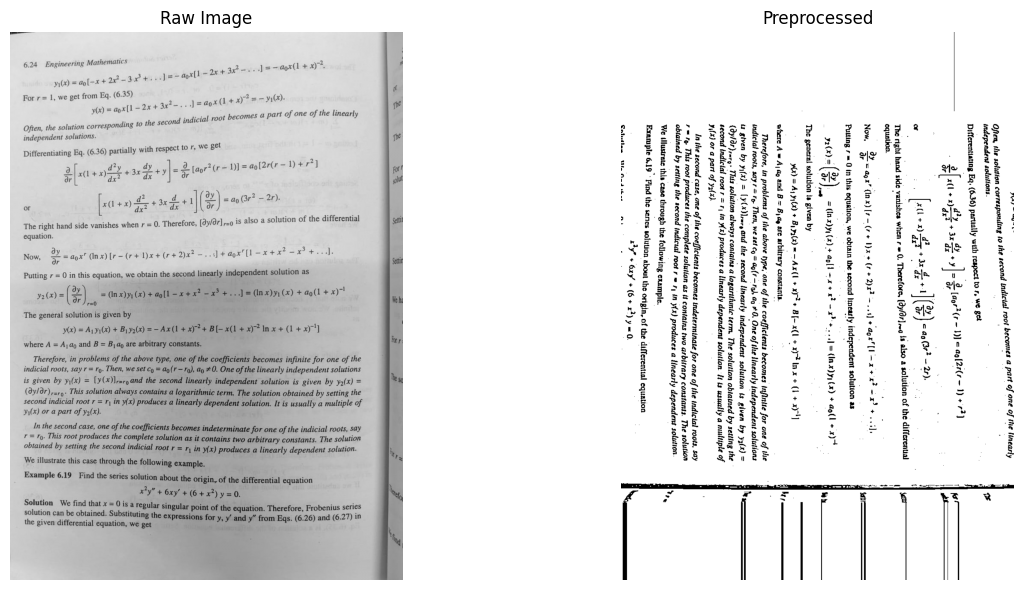

Saved comparison image ✓


In [20]:
# Change this to your actual image path
RAW_IMAGE_PATH  = '../data/raw/notes.jpeg'
PROC_IMAGE_PATH = '../data/processed/proc_sample_note.jpg'

processed = preprocess_image(
    RAW_IMAGE_PATH,
    save_path=PROC_IMAGE_PATH,
    apply_morph=True,
    clip_limit=1.0,
    denoise_strength=30
)

# Visualize side by side
raw = cv2.imread(RAW_IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(raw, cmap='gray'); axes[0].set_title('Raw Image'); axes[0].axis('off')
axes[1].imshow(processed, cmap='gray'); axes[1].set_title('Preprocessed'); axes[1].axis('off')
plt.tight_layout()
plt.savefig('../outputs/ocr_preprocessing_comparison.png', dpi=150)
plt.show()
print('Saved comparison image ✓')

## Step 2: OCR Extraction

In [21]:
# Extract text from both raw and processed
raw_result  = extract_text(RAW_IMAGE_PATH,  engine='tesseract')
proc_result = extract_text(PROC_IMAGE_PATH, engine='tesseract')

print('=== RAW OCR OUTPUT ===')
print(raw_result['text'][:500])
print(f"\nConfidence: {raw_result['confidence']}")

print('\n=== PREPROCESSED OCR OUTPUT ===')
print(proc_result['text'][:500])
print(f"\nConfidence: {proc_result['confidence']}")

[2026-04-14 03:04:18,262] [    INFO] ocr.py:104 - Running OCR [tesseract] on: notes.jpeg
[2026-04-14 03:04:19,713] [    INFO] ocr.py:104 - Running OCR [tesseract] on: proc_sample_note.jpg


=== RAW OCR OUTPUT ===
6.24 Engineering Mathematics s 5 Pe ot =— ao * oe fy Bi SOTO oe 2 4xd 4s) == orl ya) = ag[=¥ + 2° For r= 1, we get from Eq, (6.35) 2 =~ y,(2). Voom opel aoe 1 mina) mt i ‘al root becomes a part of one of the linearly i indici Often, the solution corresponding to the second in independent solutions. Differentiating Eq. (6.36) partially with respect to r, We get d?y dy Das? = 1] = aol2r(r- 1) +77) a[sarogtrey =, ear Us 2 ey Vie oa [sc rode raedeet] (F)-0 2r). s also a solution of the differential 

Confidence: 0.7208

=== PREPROCESSED OCR OUTPUT ===
| becomes a part of one of tlie linearly he second indictal root z 5 Often, the solition corresponding 10 # ! ies soluttons. paruinlly with respect to F» we Bt 2 dy Dtmrt(r-) eaglare— 1) +77) 2 faa nhac er] Flere Nea Differentiating Eq. (6.36) OF : ; i d. Y| ~2r), et ; [co deoe](¥) ag (3r a) . The right hand side vanishes when r = 0. Therefore, [2y/8r) m0 {s also a solution of the differential equation. . Now, BY aga” n

## Step 3: CER and WER Evaluation

You need to provide the **ground truth** text for the pages you test.
Type it manually for 10-15 pages — this is your validation dataset.


In [14]:
# !! Replace this with the actual correct text from the image !!
GROUND_TRUTH = """6.24 Engineering Mathematics

y1(x) = a0[-x + 2x^2 - 3x^3 + ...] = -a0x[1 - 2x + 3x^2 - ...] = -a0x(1 + x)^(-2)

For r = 1, we get from Eq. (6.35)

y(x) = a0x[1 - 2x + 3x^2 - ...] = a0x(1 + x)^(-2) = -y1(x)

Often, the solution corresponding to the second indicial root becomes a part of one of the linearly independent solutions.

Differentiating Eq. (6.36) partially with respect to r, we get

∂/∂r [ x(1 + x) d^2y/dx^2 + 3x dy/dx + y ] = ∂/∂r [ a0 r^2 (r − 1) ] = a0 [2r(r − 1) + r^2]

or

[ x(1 + x) d^2/dx^2 + 3x d/dx + 1 ] (∂y/∂r) = a0 (3r^2 − 2r)

The right hand side vanishes when r = 0. Therefore, (∂y/∂r) at r=0 is also a solution of the differential equation.

Now,

∂y/∂r = a0 x^r (ln x) [ r − (r + 1)x + (r + 2)x^2 − ... ] + a0 x^r [1 − x + x^2 − x^3 + ...]

Putting r = 0 in this equation, we obtain the second linearly independent solution as

y2(x) = (∂y/∂r) at r=0 = (ln x) y1(x) + a0 [1 − x + x^2 − x^3 + ...] = (ln x) y1(x) + a0 (1 + x)^(-1)

The general solution is given by

y(x) = A1 y1(x) + B1 y2(x) = −A x(1 + x)^(-2) + B [ −x(1 + x)^(-2) ln x + (1 + x)^(-1) ]

where A = A1 a0 and B = B1 a0 are arbitrary constants.

Therefore, in problems of the above type, one of the coefficients becomes infinite for one of the indicial roots, say r = r0. Then, we set c0 = a0 (r − r0), a0 ≠ 0. One of the linearly independent solutions is given by y1(x) = [y(x)] at r=r0 and the second linearly independent solution is given by y2(x) = (∂y/∂r) at r=r0. This solution always contains a logarithmic term. The solution obtained by setting the second indicial root r = r1 in y(x) produces a linearly dependent solution. It is usually a multiple of y1(x) or a part of y2(x).

In the second case, one of the coefficients becomes indeterminate for one of the indicial roots, say r = r0. This root produces the complete solution as it contains two arbitrary constants. The solution obtained by setting the second indicial root r = r1 in y(x) produces a linearly dependent solution.

We illustrate this case through the following example.

Example 6.19 Find the series solution about the origin, of the differential equation

x^2 y'' + 6x y' + (6 + x^2) y = 0.

Solution We find that x = 0 is a regular singular point of the equation. Therefore, Frobenius series solution can be obtained. Substituting the expressions for y, y' and y'' from Eqs. (6.26) and (6.27) in the given differential equation, we get
"""


# Evaluate
raw_eval  = evaluate_ocr(GROUND_TRUTH, raw_result['text'],  label='Raw OCR')
proc_eval = evaluate_ocr(GROUND_TRUTH, proc_result['text'], label='Preprocessed OCR')

# Pretty table
import pandas as pd
df = pd.DataFrame([
    {'Method': 'Raw OCR',         'CER': raw_eval['cer'],  'WER': raw_eval['wer'],  'CER%': raw_eval['cer_%'],  'WER%': raw_eval['wer_%']},
    {'Method': 'Preprocessed OCR','CER': proc_eval['cer'], 'WER': proc_eval['wer'], 'CER%': proc_eval['cer_%'], 'WER%': proc_eval['wer_%']},
])
print('\n── OCR Quality Evaluation Table ──────────────────')
print(df.to_string(index=False))

# Save
df.to_csv('../outputs/ocr_evaluation_results.csv', index=False)
print('\nSaved to outputs/ocr_evaluation_results.csv ✓')

[2026-04-14 03:00:50,754] [    INFO] ocr.py:205 - [Raw OCR] CER: 31.83%  WER: 53.56%
[2026-04-14 03:00:50,757] [    INFO] ocr.py:205 - [Preprocessed OCR] CER: 42.37%  WER: 62.32%



── OCR Quality Evaluation Table ──────────────────
          Method    CER    WER  CER%  WER%
         Raw OCR 0.3183 0.5356 31.83 53.56
Preprocessed OCR 0.4237 0.6232 42.37 62.32

Saved to outputs/ocr_evaluation_results.csv ✓


## Step 4: Visualize CER / WER

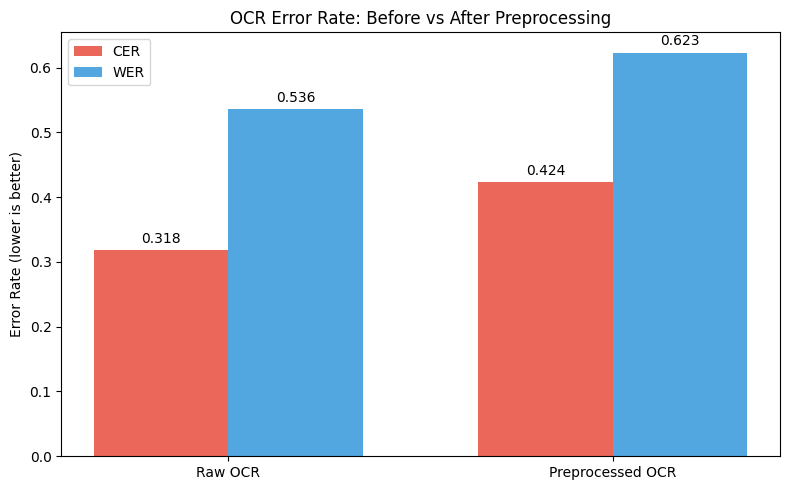

Chart saved ✓


In [15]:
labels  = ['Raw OCR', 'Preprocessed OCR']
cer_vals = [raw_eval['cer'], proc_eval['cer']]
wer_vals = [raw_eval['wer'], proc_eval['wer']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, cer_vals, width, label='CER', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, wer_vals, width, label='WER', color='#3498db', alpha=0.85)

ax.set_ylabel('Error Rate (lower is better)')
ax.set_title('OCR Error Rate: Before vs After Preprocessing')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('../outputs/ocr_error_rates.png', dpi=150)
plt.show()
print('Chart saved ✓')